# CRISP-DM na Prática: Previsão de Churn em Plataforma de Streaming

## Fase 3: Preparação dos Dados

Agora, preparamos os dados para a modelagem. Isso inclui a limpeza de dados, a transformação de variáveis e a criação de novas features (Engenharia de Features) para treinar o modelo.

A saída deve ser um novo arquivo CSV para treinamento do modelo.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent 
sys.path.append(str(ROOT))

In [2]:
# importando as bibliotecas
import pandas as pd
import os
from data_preparation.graphics_prep_data import correlation_graph, pairplot_churn
from data_understanding.download_data import download_file, return_data
import matplotlib.pyplot as plt

In [3]:
# Leitura dos dados

download_file()


df = return_data('contents/telecom_churn.csv')

Download e extração concluídos!


* Correlação e Padronização dos dados

In [4]:
# padronização dos dados (apenas nas colunas do tipo float)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Identifique suas colunas
cols_float = ['AccountWeeks','DataUsage', 'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee','RoamMins'] # Colunas contínuas
cols_binarias = ['Churn', 'ContractRenewal','DataPlan'] # Colunas 0 e 1

# Criar o transformador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_float)
    ],
    remainder='passthrough' # não altera as colunas binárias
)

# Aplicar ao DataFrame
df_processado = preprocessor.fit_transform(df)

# 2. Recupera os nomes das colunas na ordem correta
# O sklearn mantém a ordem: (colunas transformadas + colunas do passthrough)
colunas_finais = preprocessor.get_feature_names_out()

colunas_finais = [i.replace('num__','').replace('remainder__','') for i in colunas_finais]

# 3. Cria o novo DataFrame usando o índice do original
df_padronizado  = pd.DataFrame(df_processado, columns=colunas_finais, index=df.index)

In [5]:
df_padronizado.head()

,AccountWeeks,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,Churn,ContractRenewal,DataPlan
0,0.676489,1.480204,-0.427932,1.566767,0.476643,1.990727,-0.071584,-0.085008,0.0,1.0,1.0
1,0.149065,2.266072,-0.427932,-0.333738,1.124503,1.564510,-0.107082,1.240482,0.0,1.0,1.0
2,0.902529,-0.641642,-1.188218,1.168304,0.675985,-0.262133,-1.574346,0.703121,0.0,1.0,0.0
3,-0.428590,-0.641642,0.332354,2.196596,-1.466936,0.042307,-2.741846,-1.303026,0.0,0.0,0.0
4,-0.654629,-0.641642,1.092641,-0.240090,0.626149,-0.931902,-1.037927,-0.049184,0.0,0.0,0.0


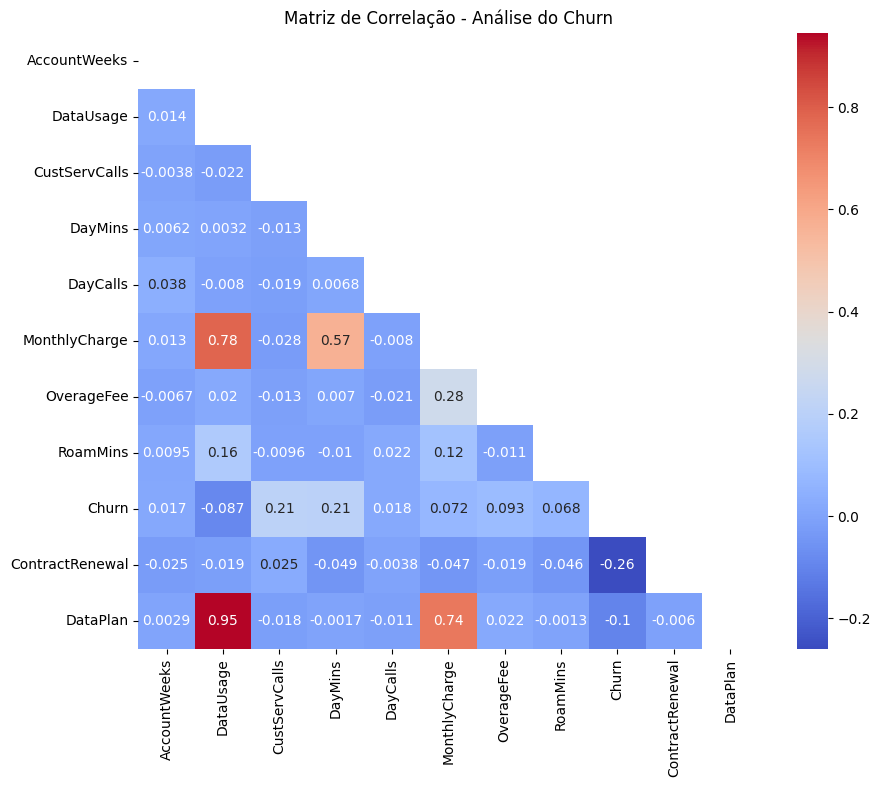

In [6]:
# verificando a correlação entre os dados
correlation_graph(df_padronizado)
plt.show()

Temos colunas que apresentam uma correlação positiva entre si:
* Datausage e Dataplan
* MonthlyCharge com Dataplan
* MonthlyCharge com Datausage
* MonthlyCharge com DayMins

Isto nos indica, por exemplo, que a feature MonthlyCharge aumenta a medida que a média de minutos aumenta (o que é esperado). Assim como, a medida que a quantidade de dados utilizados aumenta temos uma cobrança proporcional na fatura.

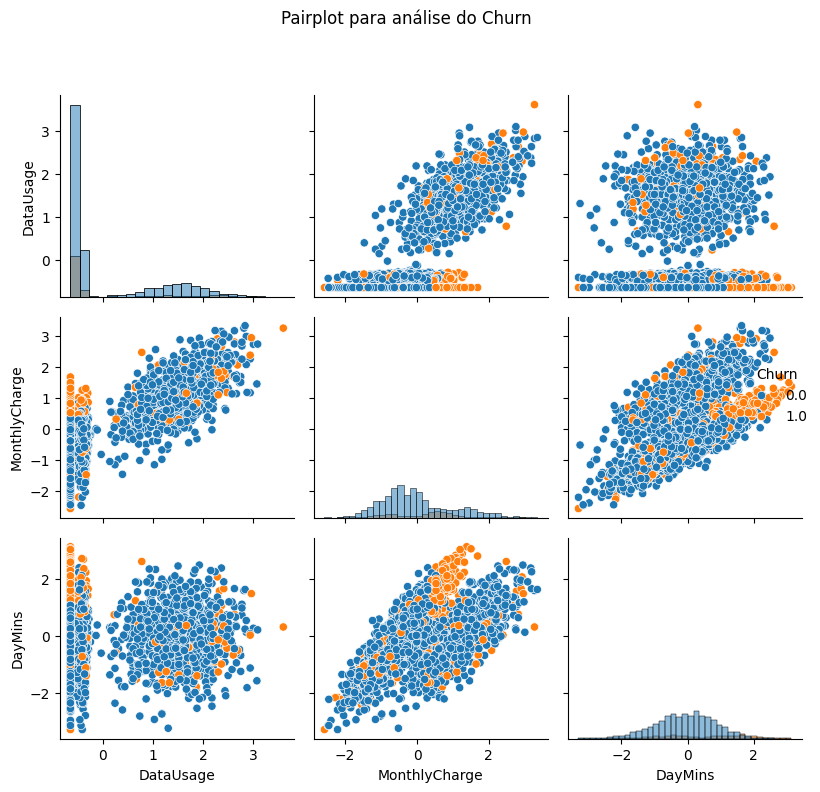

In [7]:
pairplot_churn(df_padronizado,['DataUsage','MonthlyCharge','DayMins','Churn'],'Churn')
plt.show()

Nesta distribuição, é possível observar que existe uma parcela de clientes que efetuaram o cancelamento alta a medida que a fatura aumentou e seu consumo de minutos também.

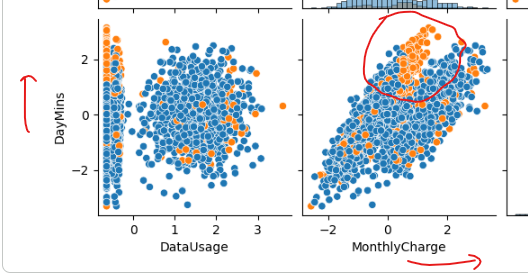

### Resumo da exploração e preparação dos dados

1. Temos dados desbalanceados, sendo necessário utilizar alguma estratégia de balanceamento para treinar um modelo.
2. A maioria das features contínuas apresentam uma distribuição aproximadamente normal nos indicando que a padronização é o mais apropriado de ser aplicada.
3. É possível perceber alguns fatores que podem influenciar no churn, sendo eles:
    * aumento de fatura a medida que a média do uso diário de minutos aumenta.
    * quantidade de ligações para o suporte acima de 4 vezes
    * efetuação da renovação do contrato, aonde existe uma quantidade maior de churn após este processo.
    * a não contratação de um plano de dados concentra a maior quantidade de clientes com churn
    * O intervalo de semanas com a conta ativa para o clientes com churn se concentram entre 50 a 150.
4. Como processo de entendimento do negócio poderia sugerir concentrar os esforços em estratégias de retenção para usuários que:
  * não tem plano de dados e obtém uma renovação recente de contrato
  * não tem plano de dados e não renovou o contrato

* Exportando os dados tratados para as próximas etapas do CRISP-DM

In [8]:
df_padronizado.to_csv(os.path.join(ROOT,'data_preparation/df_padronizado.csv'))